In [29]:
import pandas as pd

df = pd.read_csv("SuperStore_Sales_Dataset.csv")

# check nulls
print(df.isnull().sum())

# remove duplicates
df = df.drop_duplicates()

# convert order date (FIXED)
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# create new features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

df.head()

Row ID+O6G3A1:R6       0
Order ID               0
Order Date             0
Ship Date              0
Ship Mode              0
Customer ID            0
Customer Name          0
Segment                0
Country                0
City                   0
State                  0
Region                 0
Product ID             0
Category               0
Sub-Category           0
Product Name           0
Sales                  0
Quantity               0
Profit                 0
Returns             5614
Payment Mode           0
ind1                5901
ind2                5901
dtype: int64


,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Profit,Returns,Payment Mode,ind1,ind2,Year,Month
0,4918,CA-2019-160304,2019-01-01,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,"Bush Westfield Collection Bookcases, Medium Ch...",73.94,1,28.2668,NaN,Online,NaN,NaN,2019,1
1,4919,CA-2019-160304,2019-01-02,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,"Bush Westfield Collection Bookcases, Medium Ch...",173.94,3,38.2668,NaN,Online,NaN,NaN,2019,1
2,4920,CA-2019-160304,2019-01-02,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,GE 30522EE2,231.98,2,67.2742,NaN,Cards,NaN,NaN,2019,1
3,3074,CA-2019-125206,2019-01-03,05-01-2019,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,Recycled Steel Personal File for Hanging File ...,114.46,2,28.6150,NaN,Online,NaN,NaN,2019,1
4,8604,US-2019-116365,2019-01-03,08-01-2019,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,Imation Clip USB flash drive - 8 GB,30.08,2,-5.2640,NaN,Online,NaN,NaN,2019,1


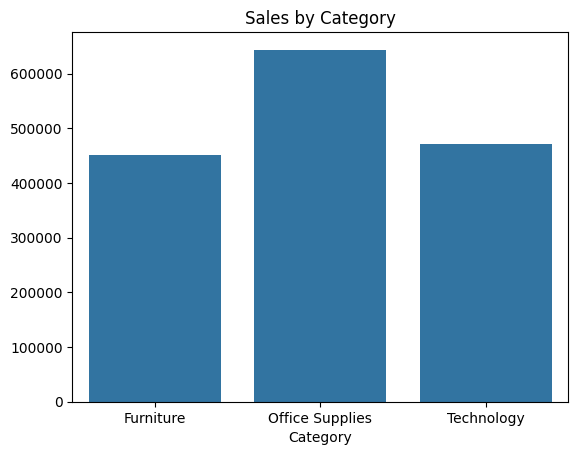

In [31]:
#EDA
import seaborn as sns
import matplotlib.pyplot as plt

sales_by_category = df.groupby('Category')['Sales'].sum()

sns.barplot(x=sales_by_category.index, y=sales_by_category.values)
plt.title("Sales by Category")
plt.show()

In [25]:
#customer segmentation
import pandas as pd
import datetime as dt

# convert date column
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# snapshot date
snapshot_date = df['Order Date'].max() + dt.timedelta(days=1)

# RFM calculation
rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (snapshot_date - x.max()).days,
    'Customer ID': 'count',
    'Sales': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,186,6,4919.552
AA-10375,21,9,2015.020
AA-10480,261,11,1862.052
AA-10645,57,9,1757.145
AB-10015,418,2,563.940


In [33]:
#kmeans
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

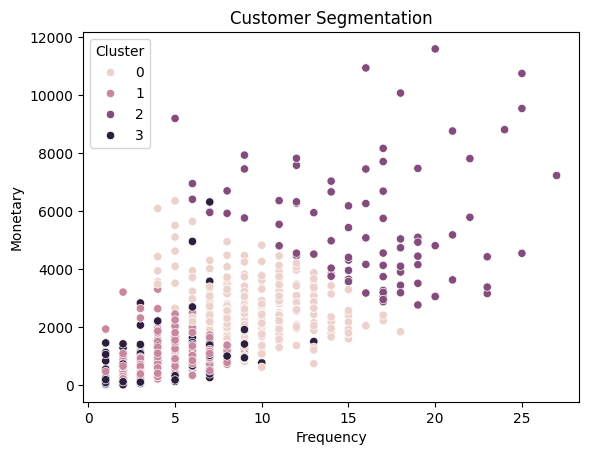

In [35]:
#visualize customer segments
sns.scatterplot(
    x=rfm['Frequency'],
    y=rfm['Monetary'],
    hue=rfm['Cluster']
)
plt.title("Customer Segmentation")
plt.show()

In [37]:
rfm.to_csv("customer_segments.csv", index=False)

In [53]:
rfm = rfm.reset_index()

In [55]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,AA-10315,186,6,4919.552,0
1,AA-10375,21,9,2015.020,0
2,AA-10480,261,11,1862.052,0
3,AA-10645,57,9,1757.145,0
4,AB-10015,418,2,563.940,3


In [57]:
rfm.to_csv(r"C:\Users\nukan\Downloads\customer_segments.csv", index=False)